# Stage 3, Track B — Feature-Based Cetacean Classifier

No deep learning, no Stage 2 reuse - mirrors Track A's strategy: measure a handful of numbers
from each annotated region (box aspect ratio, size, brightness/colour vs. surrounding water),
classify with logistic regression.

**Format confirmed:** YOLO `.txt`, one file per image, single class (id 0).

**Critical finding from a 7-image sample:** 2 of 7 images were duplicates or rotated copies of
other images in the same sample (identical box dimensions, only position differed). This notebook
treats duplicate detection as a first-class step, not an afterthought - train/eval splitting
happens by duplicate GROUP, never by individual file.

In [9]:
# --- Cell 1: Config ---
from pathlib import Path
import random

random.seed(42)

CETACEAN_IMAGES_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Stage3_TrackB\train\images")        # UPDATE THIS - folder of .jpg/.png files
CETACEAN_ANNOTATIONS_DIR = Path(r"C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Stage3_TrackB\train\labels")  # UPDATE THIS - folder of matching .txt files
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

RING_PAD_FRAC = 0.5       # ring width around each box, as a fraction of the box's own size
N_NEGATIVES_PER_IMAGE = 2  # how many empty regions to sample per image as negative examples
N_EVAL_GROUPS_TARGET = 0.2 # roughly 20% of duplicate-groups held out for eval

print("Config set.")

Config set.


In [10]:
# --- Cell 2: Load every image + its YOLO annotation ---

def load_yolo_boxes(txt_path, img_w, img_h):
    """Returns a list of (class_id, x0, y0, x1, y1) in PIXEL coordinates."""
    boxes = []
    if not txt_path.exists():
        return boxes
    for line in txt_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_id, xc, yc, w, h = int(parts[0]), *map(float, parts[1:5])
        bw, bh = w * img_w, h * img_h
        x0, y0 = (xc * img_w) - bw / 2, (yc * img_h) - bh / 2
        boxes.append((cls_id, x0, y0, x0 + bw, y0 + bh))
    return boxes

from PIL import Image

image_paths = sorted(p for p in CETACEAN_IMAGES_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
annotation_paths_by_stem = {p.stem: p for p in CETACEAN_ANNOTATIONS_DIR.rglob("*.txt")}
print(f"Found {len(annotation_paths_by_stem)} annotation files in {CETACEAN_ANNOTATIONS_DIR}")
print(f"Found {len(image_paths)} images")

records = []
n_empty = 0
for img_path in image_paths:
    txt_path = annotation_paths_by_stem.get(img_path.stem)
    if txt_path is None:
        n_empty += 1
        records.append({"path": img_path, "img_w": img_w, "img_h": img_h, "boxes": []})
        continue
    with Image.open(img_path) as im:
        img_w, img_h = im.size
    boxes = load_yolo_boxes(txt_path, img_w, img_h)
    if not boxes:
        n_empty += 1
    records.append({"path": img_path, "img_w": img_w, "img_h": img_h, "boxes": boxes})

print(f"Images with at least one box: {len(records) - n_empty}")
n_missing_file = sum(1 for r in records if r["path"].stem not in annotation_paths_by_stem)
print(f"Images with ZERO boxes: {n_empty} total "
      f"({n_missing_file} had no matching .txt file at all, "
      f"{n_empty - n_missing_file} had a .txt file that was empty)")

Found 7460 annotation files in C:\Users\bcura\AI PostGrad Project\Saqqara-Marine-Anomaly-Detection\Stage_03\Stage3_TrackB\train\labels
Found 7460 images
Images with at least one box: 5632
Images with ZERO boxes: 1828 total (0 had no matching .txt file at all, 1828 had a .txt file that was empty)


In [11]:
# --- Cell 3: Detect duplicate / rotated / flipped source photos ---
# Rotation and flipping preserve each box"s (width, height) exactly - only position changes.
# Two images sharing the same SET of box dimensions are almost certainly the same source photo.
# This is the safeguard from the 7-image sample finding: 2 of 7 were duplicates of each other.

def box_dims_fingerprint(record, decimals=3):
    dims = sorted(
        (round(x1 - x0, decimals), round(y1 - y0, decimals))
        for _, x0, y0, x1, y1 in record["boxes"]
    )
    return tuple(dims)

groups = {}   # fingerprint -> list of record indices
for i, r in enumerate(records):
    if not r["boxes"]:
        continue   # unboxed images have no fingerprint to group by - handled separately
    fp = box_dims_fingerprint(r)
    groups.setdefault(fp, []).append(i)

dup_groups = {fp: idxs for fp, idxs in groups.items() if len(idxs) > 1}
n_in_dup_groups = sum(len(idxs) for idxs in dup_groups.values())

print(f"Distinct box-dimension fingerprints (boxed images only): {len(groups)}")
print(f"Fingerprints shared by more than one image (duplicate/rotated groups): {len(dup_groups)}")
print(f"Images involved in a duplicate group: {n_in_dup_groups} of {sum(1 for r in records if r["boxes"])}")

if dup_groups:
    print("\nExample duplicate groups found:")
    for fp, idxs in list(dup_groups.items())[:5]:
        names = [records[i]["path"].name for i in idxs]
        print(f"  {names}")

# Every image gets a group id - images not in any duplicate group are their own group of size 1
group_id_of = {}
next_group_id = 0
for fp, idxs in groups.items():
    for i in idxs:
        group_id_of[i] = next_group_id
    next_group_id += 1
for i, r in enumerate(records):
    if i not in group_id_of:
        group_id_of[i] = next_group_id
        next_group_id += 1

print(f"\nTotal distinct groups (this is the REAL sample size for splitting purposes): {next_group_id}")
print(f"(vs. {len(records)} raw image files - the gap is inflation from duplicates/rotations)")

Distinct box-dimension fingerprints (boxed images only): 1648
Fingerprints shared by more than one image (duplicate/rotated groups): 1241
Images involved in a duplicate group: 5225 of 5632

Example duplicate groups found:
  ['1000_jpg.rf.946320ea54f81b9e9255f4cfe5b39852.jpg', '1000_jpg.rf.da16de0f39a5998f1844f43b45e62b73.jpg', '1400_jpg.rf.19701f2df77140c09ed7ccb9e55f3b54.jpg', '1400_jpg.rf.22f1354e044f250566ec4dcac7316b0d.jpg', '279_jpg.rf.101fc55ad7fce7c53cce654dc5142902.jpg', '3000_jpg.rf.1f6f0d340ee8983196c33c6998c9556b.jpg', '3000_jpg.rf.6da002c8d19bbce8ad264ef42347d7ac.jpg', '3800_jpg.rf.0c8ea43ab9787800cfdccb99958d87ab.jpg', '600_jpg.rf.16c2ddff6f2f92b0171e76ce2d61fb0c.jpg']
  ['1000_jpg.rf.9bec96836b3de2d8b3ec5ab7d854be2a.jpg', '3000_jpg.rf.1584776f956e46b43f30c91b8a84c8ee.jpg', '3800_jpg.rf.2416cb97f2974d6b3cde4d1c656e214c.jpg']
  ['1002_jpg.rf.36126b89ec4fa3b6c27c5a2ef7a8b784.jpg', '1402_jpg.rf.678f88f149ffc98721938a1685ca707c.jpg', '1402_jpg.rf.dcf3870bcb6acd19cc99e86b3c4612

In [12]:
# --- Cell 4: Feature extraction - box shape + brightness/colour vs. surrounding water ---

import numpy as np
import cv2

def extract_box_features(img_rgb, box, ring_pad_frac=RING_PAD_FRAC):
    """box = (x0, y0, x1, y1) in pixel coords. Returns a feature dict, or None if the box
    is degenerate or too close to the image edge to measure a ring around it."""
    H, W = img_rgb.shape[:2]
    x0, y0, x1, y1 = [int(round(v)) for v in box]
    x0, y0 = max(0, x0), max(0, y0)
    x1, y1 = min(W, x1), min(H, y1)
    bw, bh = x1 - x0, y1 - y0
    if bw < 4 or bh < 4:
        return None

    pad_x, pad_y = int(bw * ring_pad_frac), int(bh * ring_pad_frac)
    rx0, ry0 = max(0, x0 - pad_x), max(0, y0 - pad_y)
    rx1, ry1 = min(W, x1 + pad_x), min(H, y1 + pad_y)

    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    inside_mask = np.zeros((H, W), dtype=bool)
    inside_mask[y0:y1, x0:x1] = True
    ring_mask = np.zeros((H, W), dtype=bool)
    ring_mask[ry0:ry1, rx0:rx1] = True
    ring_mask &= ~inside_mask
    if ring_mask.sum() < 20:
        return None

    L, a, b = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]
    aspect_ratio = max(bw, bh) / max(1, min(bw, bh))
    relative_area = (bw * bh) / (W * H)

    return {
        "aspect_ratio": aspect_ratio,
        "relative_area": relative_area,
        "in_L": float(L[inside_mask].mean()), "ring_L": float(L[ring_mask].mean()),
        "contrast_L": float(L[inside_mask].mean() - L[ring_mask].mean()),
        "in_a": float(a[inside_mask].mean()), "ring_a": float(a[ring_mask].mean()),
        "in_b": float(b[inside_mask].mean()), "ring_b": float(b[ring_mask].mean()),
        "in_L_std": float(L[inside_mask].std()),
    }

FEATURE_COLS_ALL = ["aspect_ratio", "relative_area", "in_L", "ring_L", "contrast_L",
                     "in_a", "ring_a", "in_b", "ring_b", "in_L_std"]
SHAPE_FEATURES = ["aspect_ratio", "relative_area"]
SIGNATURE_FEATURES = ["contrast_L", "in_a", "ring_a", "in_b", "ring_b", "in_L_std"]

print("Feature function ready.")

Feature function ready.


In [13]:
# --- Cell 5: Sample negative (non-cetacean) regions from the SAME photos ---
# Keeps the same aspect-ratio distribution as real boxes, to avoid teaching the classifier
# "small boxes = cetacean" by accident. Checks for zero overlap with any real box.

def boxes_overlap(a, b):
    ax0, ay0, ax1, ay1 = a; bx0, by0, bx1, by1 = b
    return not (ax1 <= bx0 or bx1 <= ax0 or ay1 <= by0 or by1 <= ay0)

def sample_negative_boxes(record, n_needed, max_tries=50):
    W, H = record["img_w"], record["img_h"]
    real_boxes = [(x0, y0, x1, y1) for _, x0, y0, x1, y1 in record["boxes"]]
    if real_boxes:
        widths = [x1 - x0 for x0, y0, x1, y1 in real_boxes]
        heights = [y1 - y0 for x0, y0, x1, y1 in real_boxes]
    else:
        widths, heights = [W * 0.1], [H * 0.1]   # fallback size for fully-unboxed images

    out = []
    for _ in range(n_needed):
        for _try in range(max_tries):
            bw, bh = random.choice(widths), random.choice(heights)
            x0 = random.uniform(0, max(1, W - bw))
            y0 = random.uniform(0, max(1, H - bh))
            cand = (x0, y0, x0 + bw, y0 + bh)
            if not any(boxes_overlap(cand, rb) for rb in real_boxes):
                out.append(cand)
                break
    return out

In [14]:
# --- Cell 6: Extract features for every positive and negative example ---

rows = []
for i, r in enumerate(records):
    try:
        img = np.array(Image.open(r["path"]).convert("RGB"))
    except Exception as e:
        print(f"Could not open {r["path"].name}: {e}")
        continue

    for _, x0, y0, x1, y1 in r["boxes"]:
        feats = extract_box_features(img, (x0, y0, x1, y1))
        if feats is None:
            continue
        feats.update(label="cetacean", group_id=group_id_of[i], filename=r["path"].name,
                      box=(x0, y0, x1, y1))
        rows.append(feats)

    neg_boxes = sample_negative_boxes(r, N_NEGATIVES_PER_IMAGE)
    for nb in neg_boxes:
        feats = extract_box_features(img, nb)
        if feats is None:
            continue
        feats.update(label="not_cetacean", group_id=group_id_of[i], filename=r["path"].name,
                      box=nb)
        rows.append(feats)

n_pos = sum(1 for row in rows if row["label"] == "cetacean")
n_neg = sum(1 for row in rows if row["label"] == "not_cetacean")
print(f"Extracted {len(rows)} rows total: {n_pos} cetacean, {n_neg} not_cetacean")
print(f"From {len(set(row["group_id"] for row in rows))} distinct source-photo groups")

Extracted 34770 rows total: 19850 cetacean, 14920 not_cetacean
From 3476 distinct source-photo groups


In [15]:
# --- Cell 7: Train/eval split BY GROUP, never by individual file ---
# This is the safeguard: a duplicate or rotated copy of a training image can never end up in eval.

all_group_ids = sorted(set(row["group_id"] for row in rows))
random.shuffle(all_group_ids)
n_eval_groups = max(1, int(len(all_group_ids) * N_EVAL_GROUPS_TARGET))
eval_group_ids = set(all_group_ids[:n_eval_groups])
train_group_ids = set(all_group_ids[n_eval_groups:])

train_rows = [row for row in rows if row["group_id"] in train_group_ids]
eval_rows = [row for row in rows if row["group_id"] in eval_group_ids]

print(f"Groups: {len(train_group_ids)} train, {len(eval_group_ids)} eval")
print(f"Rows:   {len(train_rows)} train "
      f"(cetacean={sum(r["label"]=="cetacean" for r in train_rows)}, "
      f"not_cetacean={sum(r["label"]=="not_cetacean" for r in train_rows)})")
print(f"        {len(eval_rows)} eval  "
      f"(cetacean={sum(r["label"]=="cetacean" for r in eval_rows)}, "
      f"not_cetacean={sum(r["label"]=="not_cetacean" for r in eval_rows)})")

overlap_check = train_group_ids & eval_group_ids
assert not overlap_check, f"BUG: {len(overlap_check)} groups appear in both train and eval"
print("\nConfirmed: zero groups appear in both train and eval.")

Groups: 2781 train, 695 eval
Rows:   27792 train (cetacean=15876, not_cetacean=11916)
        6978 eval  (cetacean=3974, not_cetacean=3004)

Confirmed: zero groups appear in both train and eval.


In [16]:
# --- Cell 8: Choose the feature set by cross-validation on TRAINING rows only ---
# Same discipline as Track A - the eval set is not touched until cell 9.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, recall_score

def to_matrix(row_list, cols):
    return np.array([[r[c] for c in cols] for r in row_list], dtype=float)

def make_model():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))

y_train = np.array([r["label"] for r in train_rows])
y_eval = np.array([r["label"] for r in eval_rows])
LABELS = ["cetacean", "not_cetacean"]

FEATURE_SETS = {
    "shape_only": SHAPE_FEATURES,
    "signature_only": SIGNATURE_FEATURES,
    "everything": FEATURE_COLS_ALL,
}

min_class = min((y_train == l).sum() for l in LABELS)
n_splits = min(5, max(2, min_class))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"{n_splits}-fold cross-validation on {len(train_rows)} training rows\n")

cv_results = {}
print(f"{"feature set":<16} | {"macro-F1":>8} | {"cetacean recall":>15} | {"not_cetacean recall":>19}")
for name, cols in FEATURE_SETS.items():
    y_cv = cross_val_predict(make_model(), to_matrix(train_rows, cols), y_train, cv=cv)
    macro = f1_score(y_train, y_cv, average="macro")
    recalls = recall_score(y_train, y_cv, labels=LABELS, average=None)
    cv_results[name] = macro
    print(f"{name:<16} | {macro:8.3f} | {recalls[0]:15.3f} | {recalls[1]:19.3f}")

selected = max(cv_results, key=cv_results.get)
print(f"\nSelected feature set: {selected} ({cv_results[selected]:.3f} macro-F1)")

5-fold cross-validation on 27792 training rows

feature set      | macro-F1 | cetacean recall | not_cetacean recall
shape_only       |    0.537 |           0.440 |               0.667
signature_only   |    0.846 |           0.796 |               0.914
everything       |    0.850 |           0.805 |               0.913

Selected feature set: everything (0.850 macro-F1)


In [17]:
# --- Cell 9: Score the selected model on the held-out eval set (once) ---

from sklearn.metrics import classification_report, confusion_matrix

cols = FEATURE_SETS[selected]
final_model = make_model().fit(to_matrix(train_rows, cols), y_train)
y_pred = final_model.predict(to_matrix(eval_rows, cols))

print(f"HELD-OUT EVAL - feature set: {selected}\n")
print(classification_report(y_eval, y_pred, labels=LABELS, digits=3, zero_division=0))

print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_eval, y_pred, labels=LABELS)
print(f"{"":>14}" + "".join(f"{l:>14}" for l in LABELS))
for i, l in enumerate(LABELS):
    print(f"{l:>14}" + "".join(f"{cm[i, j]:>14}" for j in range(len(LABELS))))

HELD-OUT EVAL - feature set: everything

              precision    recall  f1-score   support

    cetacean      0.919     0.806     0.859      3974
not_cetacean      0.779     0.906     0.838      3004

    accuracy                          0.849      6978
   macro avg      0.849     0.856     0.848      6978
weighted avg      0.859     0.849     0.850      6978

Confusion matrix (rows=true, cols=predicted):
                    cetacean  not_cetacean
      cetacean          3204           770
  not_cetacean           283          2721


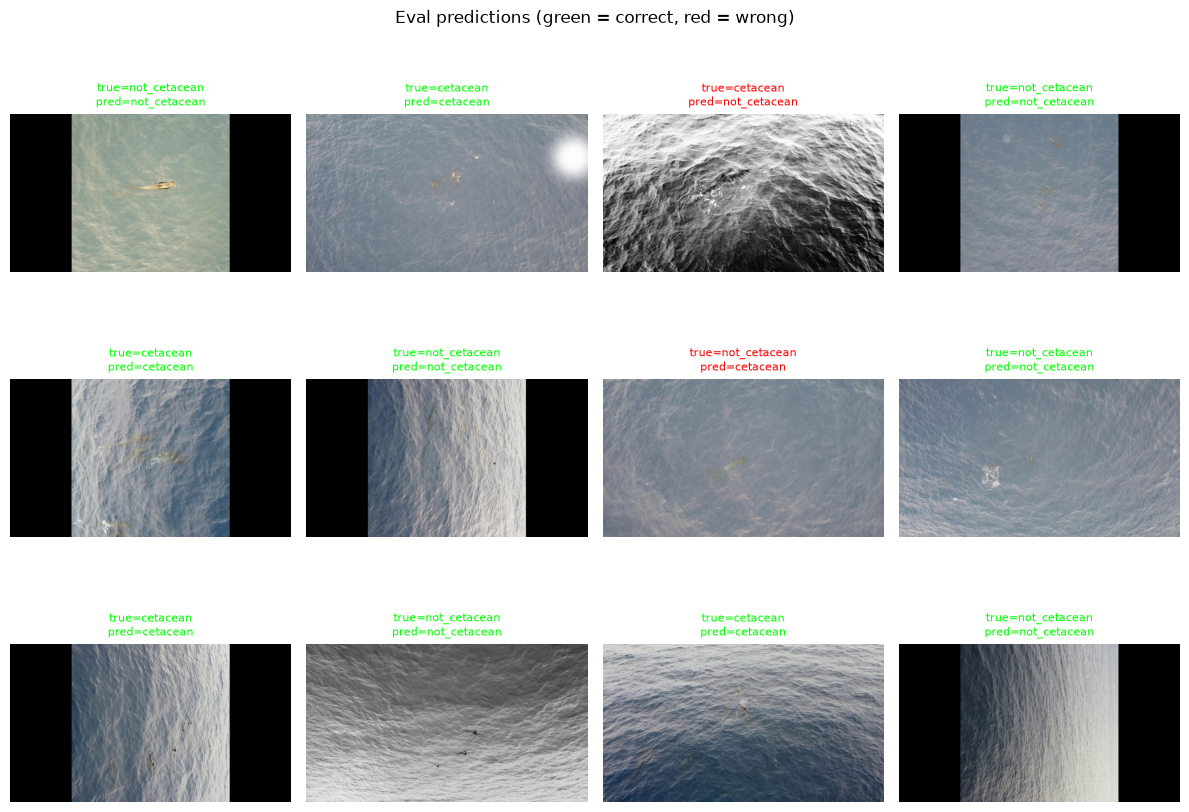

In [18]:
# --- Cell 10: Visual sample of eval predictions ---

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_SHOW = 12
sample_rows = random.sample(eval_rows, min(N_SHOW, len(eval_rows)))
n_cols = 4
n_rows = (len(sample_rows) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for ax, row in zip(axes, sample_rows):
    img_path = next(r["path"] for r in records if r["path"].name == row["filename"])
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    x = np.array([[row[c] for c in cols]], dtype=float)
    pred = final_model.predict(x)[0]
    color = "lime" if pred == row["label"] else "red"
    ax.set_title(f"true={row["label"]}\npred={pred}", fontsize=8, color=color)
    ax.axis("off")
for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.suptitle("Eval predictions (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Group-level accuracy, and seeing the actual predictions

**Why this is needed:** one real source photo was duplicated 11 times in this dataset. Row-level
accuracy (cell 9) weights that photo 11x more than a photo appearing once - the model's score on
that one duplicated photo counts 11 times over. Cell 11 below fixes this: each independent photo
group gets exactly ONE vote, regardless of how many duplicate copies exist.

Cells 12-15 show actual images: what got predicted correctly, and what got missed, for both
classes - sampled rather than showing all 6,978 eval rows.

**Requires Cell 6 to have been re-run** with the box-coordinates addition above, since drawing a
box on an image needs to know where that box actually was.

In [19]:
# --- Cell 11: Group-level accuracy - one vote per independent photo, not per row ---

from collections import defaultdict

by_group_label = defaultdict(list)
for row, pred in zip(eval_rows, y_pred):
    by_group_label[(row["group_id"], row["label"])].append(pred == row["label"])

group_majority_correct = {
    key: (sum(correct_list) / len(correct_list)) >= 0.5
    for key, correct_list in by_group_label.items()
}

print("Group-level accuracy (each independent photo counts once, however many duplicate copies it has):\n")
all_correct, all_total = 0, 0
for label in LABELS:
    keys = [k for k in group_majority_correct if k[1] == label]
    n_correct = sum(group_majority_correct[k] for k in keys)
    all_correct += n_correct
    all_total += len(keys)
    print(f"  {label:<14} {n_correct:>4} / {len(keys):<4} groups correct  ({n_correct / len(keys):.1%})")

print(f"\n  overall        {all_correct:>4} / {all_total:<4} groups correct  ({all_correct / all_total:.1%})")
print(f"\nCompare to row-level accuracy from cell 9: {(y_pred == y_eval).mean():.1%} (across {len(y_eval)} rows)")

n_multi_copy_groups = sum(1 for label in LABELS for k in by_group_label if k[1] == label and len(by_group_label[k]) > 1)
print(f"\n{n_multi_copy_groups} (group, label) combinations in eval had more than one row "
      f"(duplicate copies or multiple boxes) - these no longer get extra weight in the score above.")

Group-level accuracy (each independent photo counts once, however many duplicate copies it has):

  cetacean        259 / 335  groups correct  (77.3%)
  not_cetacean    684 / 695  groups correct  (98.4%)

  overall         943 / 1030 groups correct  (91.6%)

Compare to row-level accuracy from cell 9: 84.9% (across 6978 rows)

1022 (group, label) combinations in eval had more than one row (duplicate copies or multiple boxes) - these no longer get extra weight in the score above.


In [20]:
# --- Cell 12: Shared helper for the prediction galleries ---

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

PER_FIGURE = 15
N_SHOW = 15

def select_rows(true_label, was_correct):
    return [(row, pred) for row, pred in zip(eval_rows, y_pred)
            if row["label"] == true_label and (pred == row["label"]) == was_correct]

def plot_rows(selected, title):
    if not selected:
        print(f"{title}: none found.")
        return
    sample = random.sample(selected, min(N_SHOW, len(selected)))
    n_batches = (len(sample) + PER_FIGURE - 1) // PER_FIGURE
    for b in range(n_batches):
        batch = sample[b * PER_FIGURE:(b + 1) * PER_FIGURE]
        fig, axes = plt.subplots(len(batch), 1, figsize=(5, 4 * len(batch)))
        axes = [axes] if len(batch) == 1 else axes
        for ax, (row, pred) in zip(axes, batch):
            img_path = CETACEAN_IMAGES_DIR / row["filename"]
            try:
                img = Image.open(img_path).convert("RGB")
            except Exception:
                ax.axis("off")
                continue
            ax.imshow(img)
            x0, y0, x1, y1 = row["box"]
            color = "lime" if pred == row["label"] else "red"
            ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                              fill=False, edgecolor=color, linewidth=2))
            filename_short = row["filename"][:34]
            true_label = row["label"]
            ax.set_title(f"{filename_short}\ntrue={true_label}  predicted={pred}", fontsize=8)
            ax.axis("off")
        plt.suptitle(f"{title} (batch {b + 1}/{n_batches}, showing {len(sample)} of {len(selected)} total)")
        plt.tight_layout()
        plt.show()

print("Gallery helper ready.")


Gallery helper ready.


In [29]:
# --- Correctly predicted cetacean ---
# plot_rows(select_rows("cetacean", was_correct=True), "Correctly predicted cetacean")

In [30]:
# --- Missed cetacean (a real sighting the model called "not cetacean") ---
# plot_rows(select_rows("cetacean", was_correct=False), "Missed cetacean (false negative)")

In [31]:
# --- Correctly predicted not_cetacean ---
# plot_rows(select_rows("not_cetacean", was_correct=True), "Correctly predicted not_cetacean")

In [32]:
# --- Correctly predicted not_cetacean ---
# plot_rows(select_rows("not_cetacean", was_correct=True), "Correctly predicted not_cetacean")

In [33]:
# --- False alarm (plain water the model wrongly called "cetacean") ---
# plot_rows(select_rows("not_cetacean", was_correct=False), "False alarm (water called cetacean)")

## Testing the hypothesis: are missed cetaceans mostly never-duplicated sightings?

Before changing anything, this checks directly: does a cetacean sighting's duplicate-group
size (how many times that same photo was saved) predict whether the model gets it right?
If missed sightings cluster at group size 1 (never duplicated), that confirms the theory that
easy, duplicated sightings were inflating the row-level score - and it points at the real
weak spot: rare, one-off sightings specifically, not cetacean detection in general.


Correctly predicted cetacean (n=3204):
  mean group size:   4.88
  median group size: 5
  never-duplicated (group size 1): 276 (8.6%)

Missed cetacean (n=770):
  mean group size:   3.84
  median group size: 3
  never-duplicated (group size 1): 107 (13.9%)

CONFIRMED DIRECTION: missed sightings have smaller duplicate groups on average than
correct ones - consistent with "easy sightings got duplicated more, propping up the
row-level score". The real weak spot is rare, never-duplicated sightings specifically.


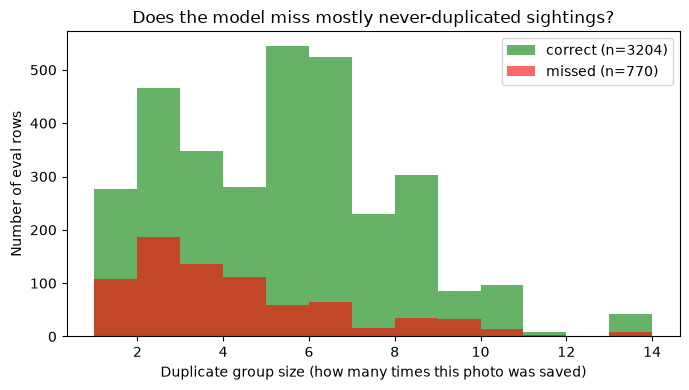

In [25]:
# --- Group-size diagnostic: numeric test of the hypothesis ---

from collections import Counter
import numpy as np

group_size_of = Counter(group_id_of.values())  # group_id -> how many duplicate images share it

correct_pairs = select_rows("cetacean", was_correct=True)
missed_pairs = select_rows("cetacean", was_correct=False)

correct_sizes = [group_size_of[row["group_id"]] for row, pred in correct_pairs]
missed_sizes = [group_size_of[row["group_id"]] for row, pred in missed_pairs]

def summarize(sizes, label):
    n_singleton = sum(1 for s in sizes if s == 1)
    print(f"{label} (n={len(sizes)}):")
    print(f"  mean group size:   {np.mean(sizes):.2f}")
    print(f"  median group size: {np.median(sizes):.0f}")
    print(f"  never-duplicated (group size 1): {n_singleton} ({n_singleton / len(sizes):.1%})")

summarize(correct_sizes, "Correctly predicted cetacean")
print()
summarize(missed_sizes, "Missed cetacean")

print()
if np.mean(missed_sizes) < np.mean(correct_sizes):
    print("CONFIRMED DIRECTION: missed sightings have smaller duplicate groups on average than")
    print("correct ones - consistent with \"easy sightings got duplicated more, propping up the")
    print("row-level score\". The real weak spot is rare, never-duplicated sightings specifically.")
else:
    print("NOT CONFIRMED: missed sightings do not have smaller duplicate groups on average.")
    print("The weakness looks more evenly spread - likely a genuine feature-set limitation")
    print("rather than a quirk of which sightings happened to be duplicated more.")

fig, ax = plt.subplots(figsize=(7, 4))
max_size = max(max(correct_sizes), max(missed_sizes))
bins = range(1, max_size + 2)
ax.hist(correct_sizes, bins=bins, alpha=0.6, label=f"correct (n={len(correct_sizes)})", color="green")
ax.hist(missed_sizes, bins=bins, alpha=0.6, label=f"missed (n={len(missed_sizes)})", color="red")
ax.set_xlabel("Duplicate group size (how many times this photo was saved)")
ax.set_ylabel("Number of eval rows")
ax.set_title("Does the model miss mostly never-duplicated sightings?")
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
# --- Gallery sorted by group size, so the hardest (least-duplicated) cases show first ---

def plot_rows_sorted_by_group_size(selected, title, ascending=True):
    if not selected:
        print(f"{title}: none found.")
        return
    selected_sorted = sorted(selected, key=lambda rp: group_size_of[rp[0]["group_id"]], reverse=not ascending)
    sample = selected_sorted[:N_SHOW]
    n_batches = (len(sample) + PER_FIGURE - 1) // PER_FIGURE
    for b in range(n_batches):
        batch = sample[b * PER_FIGURE:(b + 1) * PER_FIGURE]
        fig, axes = plt.subplots(len(batch), 1, figsize=(5, 4 * len(batch)))
        axes = [axes] if len(batch) == 1 else axes
        for ax, (row, pred) in zip(axes, batch):
            img_path = CETACEAN_IMAGES_DIR / row["filename"]
            try:
                img = Image.open(img_path).convert("RGB")
            except Exception:
                ax.axis("off")
                continue
            ax.imshow(img)
            x0, y0, x1, y1 = row["box"]
            color = "lime" if pred == row["label"] else "red"
            ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                              fill=False, edgecolor=color, linewidth=2))
            group_size = group_size_of[row["group_id"]]
            filename_short = row["filename"][:30]
            true_label = row["label"]
            ax.set_title(f"{filename_short}\ngroup_size={group_size}  true={true_label}  predicted={pred}", fontsize=8)
            ax.axis("off")
        order_word = "smallest" if ascending else "largest"
        plt.suptitle(f"{title} - sorted {order_word} group first (batch {b + 1}/{n_batches})")
        plt.tight_layout()
        plt.show()

print("Sorted gallery helper ready.")


Sorted gallery helper ready.


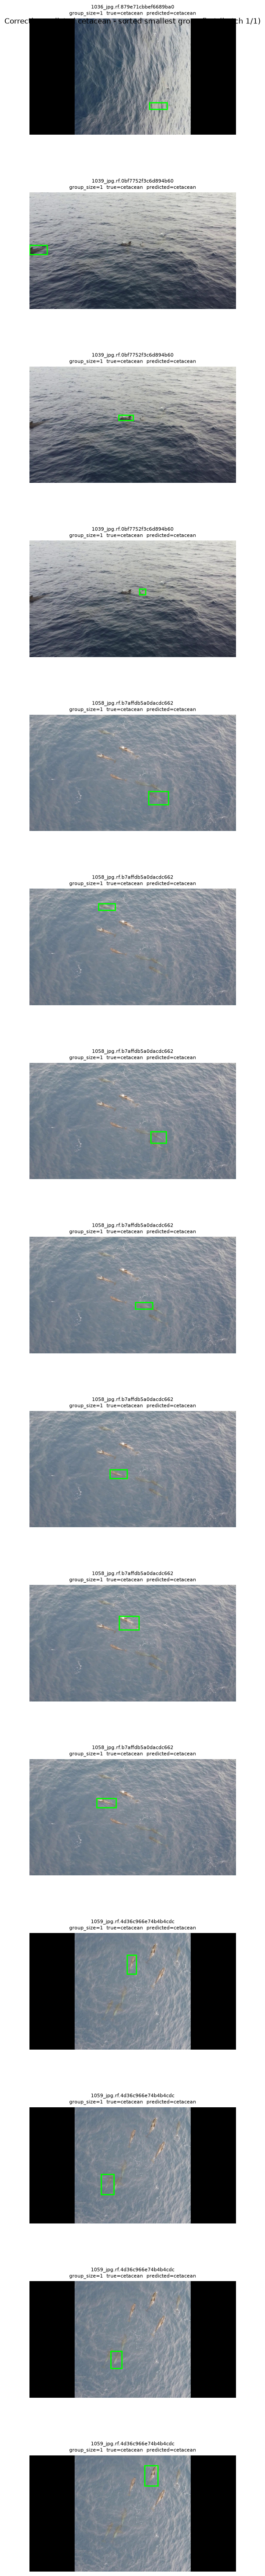

In [34]:
# --- Correctly predicted cetacean, hardest (smallest group) first ---
plot_rows_sorted_by_group_size(select_rows("cetacean", was_correct=True),
                                 "Correctly predicted cetacean", ascending=True)

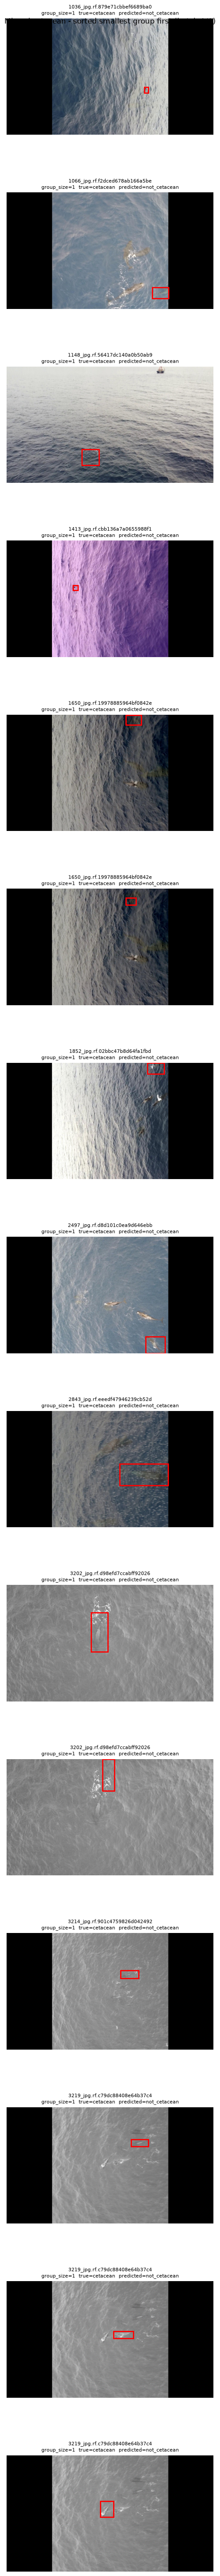

In [35]:
# --- Missed cetacean, hardest (smallest group) first ---
plot_rows_sorted_by_group_size(select_rows("cetacean", was_correct=False),
                                 "Missed cetacean", ascending=True)
